In [1]:
import numpy as np
from PIL import Image
import glob

----
#### 유사이미지

In [2]:
dirNames = ['Aiden','Andrew','Cathy']

In [3]:
for name in dirNames:
   count = 0
   for file in sorted(glob.glob(f"../Data/Face/{name}/*.jpg")):
      img = Image.open(file)
      for angle in range(-15,15,1):
         count += 1
         # 회전
         img2 = img.rotate(angle)
         img2.save(f"../Data/FaceColor/{name}/rotation_{count:04}.jpg")

         # 플립
         img3 = img2.transpose(Image.FLIP_LEFT_RIGHT)
         img3.save(f"../Data/FaceColor/{name}/flip_{count:04}.jpg")



In [ ]:
# 이름별 전체 파일 갯수
18 * 30 * 2 

----
#### 전체 사진 중 최대 해상도 찾기
: Feature의 수를 동일하게 하기 위함


In [4]:
widthRatio = []
heightRatio = []

count = 0 # file 개수 확인

for name in dirNames:
   count = 0
   for file in sorted(glob.glob(f"../Data/FaceColor/{name}/*.jpg")):
      img = np.array(Image.open(file),dtype=np.int32)
      widthRatio.append(img.shape[1])
      heightRatio.append(img.shape[0])
      count += 1
   print(f"{name} : {count}")   

Aiden : 1080
Andrew : 1080
Cathy : 1080


In [ ]:
# 최대 해상도 
print("너비 최대 해상도: ", np.max(widthRatio))
print("높이 최대 해상도: ", np.max(heightRatio))

> 해상도의 크기를 400*300으로 고정


----
#### 전체 사진을 흑백이미지로 변환하여 400*300의 크기 이미지로 이동하기

In [5]:
for name in dirNames:
   fileCount = 0
   for file in sorted(glob.glob(f"../Data/FaceColor/{name}/*.jpg")):
      img = Image.open(file)
      # img = img.convert('L')
      imgArray = np.array(img)
      imgDummy = np.zeros(400*300*3).reshape(400,300,3)
      rowNum = (400 - imgArray.shape[0]) / 2
      colNum = (300 - imgArray.shape[1]) / 2

      k=0
      for i in range(int(rowNum), int(rowNum) + imgArray.shape[0]):
         l=0
         for j in range(int(colNum), int(colNum) + imgArray.shape[1]):
            imgDummy[i,j] = imgArray[k,l]
            l+=1
         k+=1
      img2 = Image.fromarray(imgDummy.astype('uint8'))
      img2.save(f"../Data/FaceResult/{name}/image_{fileCount:04}.jpg", "JPEG")
      fileCount+=1

----
#### 사진들을 numpy 배열로 Train Data 만들기

In [6]:
number_of_data = 1080 * len(dirNames)
img_width_size = 300
img_height_size = 400
img_color = 3

In [8]:
1080 * len(dirNames) * 300 * 400 * 3


1166400000

In [12]:
train = np.zeros(
   number_of_data * img_width_size * img_height_size * img_color, dtype=np.int32
).reshape(number_of_data, img_height_size, img_width_size, img_color) # (Dimension, row, Column)

i = 0 
for name in dirNames:
   for file in sorted(glob.glob(f"../Data/FaceResult/{name}/*.jpg")):
      img = np.array(Image.open(file), dtype=np.int32)
      train[i,:,:,:] = img
      i+=1

In [ ]:
train.shape

----
#### 이미지 확인

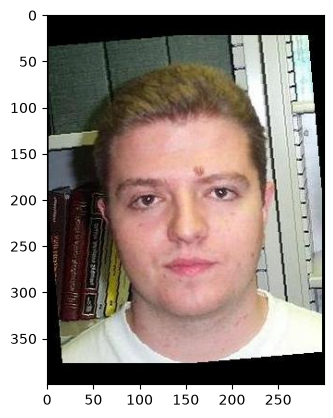

In [13]:
import matplotlib.pyplot as plt

plt.imshow(train[100].reshape(400,300,3))
plt.show()


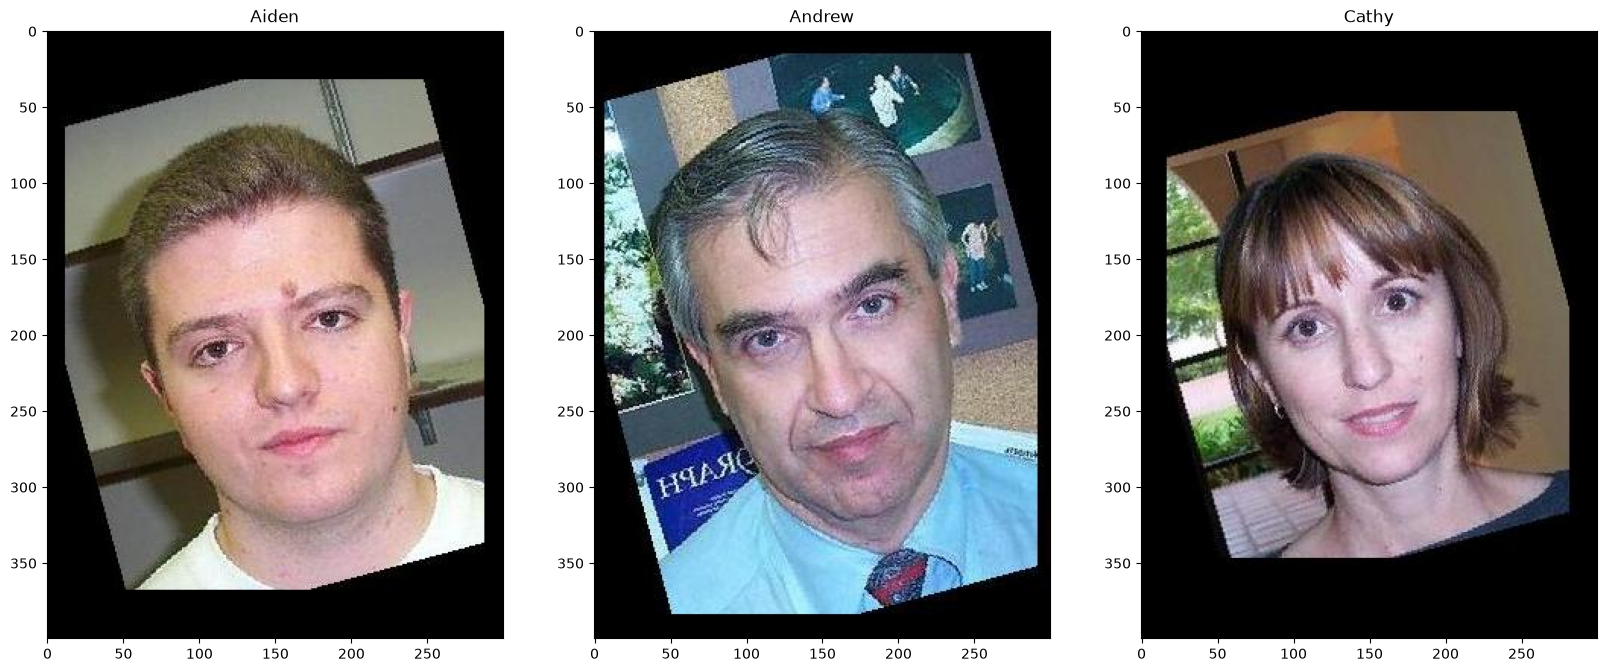

In [14]:
plt.figure(figsize=(20,20))
orderNo = list(range(0, 1080*len(dirNames), 1080))

for i in range(1, len(dirNames)+1):
   plt.subplot(1,len(dirNames), i)
   plt.imshow(train[orderNo[i-1]].reshape(400,300,3))
   plt.title(dirNames[i-1])

plt.show()

In [15]:
target = np.concatenate(
   [np.zeros(1080), np.ones(1080), np.full(1080,2)]
)
target

array([0., 0., 0., ..., 2., 2., 2.])

#### 채널 차원 추가와 정규화

In [16]:
train = train.reshape(-1,400,300,3) / 255.0


#### Train과 Test 분리

In [17]:
from sklearn.model_selection import train_test_split

trainData, testData, trainTarget, testTarget = \
   train_test_split(
      train,
      target,
      test_size=0.2,
      random_state=42
   )

In [18]:
print(trainData.shape)
print(testData.shape)
print(trainTarget.shape)
print(testTarget.shape)

(2592, 400, 300, 3)
(648, 400, 300, 3)
(2592,)
(648,)


-----
#### CNN 만들기

In [19]:
from tensorflow import keras
from tensorflow.keras.layers import Input

2026-07-10 14:16:52.951014: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [20]:
model = keras.Sequential()
# 입력층
model.add(
   Input(shape = (400,300,3))
)
# ---- 합성곱픙 만들기 ----

# 첫번째 합성곱층
model.add (
   keras.layers.Conv2D(
      32,
      kernel_size = 3,
      activation='relu',
      padding='same'
   )
)

model.add(
   keras.layers.MaxPooling2D(2)
)

# 2번째 합성곱층
model.add (
   keras.layers.Conv2D(
      64,
      kernel_size = 3,
      activation='relu',
      padding='same'
   )
)

model.add(
   keras.layers.MaxPooling2D(2)
)

In [21]:
# 심층 신경망 만들기

model.add(
   keras.layers.Flatten()
)

# 심층 신경망의 은닉층
model.add(
   keras.layers.Dense(
      100,
      activation='relu'
   )
)

# Drop put 층 : 과대 적합 방지
model.add(
   keras.layers.Dropout(0.2) # 20% 정도의 데이터는 학습시 뺴고 한다
)

# 출력층
model.add(
   keras.layers.Dense(
      len(dirNames),
      activation='softmax'
   )
)

In [22]:
# 각 층의 순서 확인

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 400, 300, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 200, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 150, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 100, 75, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 480000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │    48,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,019,795 (183.18 MB)

 Trainable params: 48,019,795 (183.18 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# 손실함수와 학습율 정의
model.compile(
   optimizer='adam',
   loss='sparse_categorical_crossentropy',
   metrics=['accuracy']
)

# 최적의 함수 저장
checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_cnn_3P.keras")

# Epoch 실행 횟수 제한
early_stopping_cb = keras.callbacks.EarlyStopping(
   patience=5,
   restore_best_weights=True
)

In [ ]:
history = model.fit(
   trainData,
   trainTarget,
   epochs = 10,
   validation_data = (testData,testTarget),
   callbacks=[checkpoint_cb,early_stopping_cb]
)

In [ ]:
model.evaluate(trainData, trainTarget)

In [ ]:
model.evaluate(testData, testTarget)

In [ ]:
# 시각화 해보기
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train','test'])


#### 확인해 보기


In [ ]:
plt.imshow(testData[0].reshape(400,300), cmap='gray')


In [ ]:
model.predict(testData[:1])

In [ ]:
plt.imshow(testData[10].reshape(400,300), cmap='gray')
plt.show()

In [ ]:
np.argmax(model.predict(testData[10:11]))

In [ ]:
dirNames[np.argmax(model.predict(testData[10:11]))] # dirNames가 list의 형태임